In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploring data

In [ ]:
df = pd.read_csv('/content/project_risk_raw_dataset.csv')
df

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,PROJ_3996,IT,9,731548.97,14,5.40,9,Agile,Senior,4,...,Moderate,Occasional,NaN,NaN,Hybrid,Basic,10,1,1.1,High
3996,PROJ_3997,Healthcare,9,492981.40,9,2.69,8,Waterfall,Senior,5,...,Stable,Occasional,NaN,Basic,Hybrid,Basic,9,1,1.0,Medium
3997,PROJ_3998,IT,12,1097040.65,24,8.82,10,Kanban,Junior,2,...,Moderate,Regular,NaN,Basic,Fully Remote,Basic,3,4,1.0,High
3998,PROJ_3999,R&D,26,2900977.55,28,10.00,26,Scrum,Junior,1,...,High,Strategic,Basic,Formal,Fully Remote,Good,1,10,1.0,High


In [ ]:
df.drop(['Project_ID'], axis = 1, inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_Type                     4000 non-null   object 
 1   Team_Size                        4000 non-null   int64  
 2   Project_Budget_USD               4000 non-null   float64
 3   Estimated_Timeline_Months        4000 non-null   int64  
 4   Complexity_Score                 4000 non-null   float64
 5   Stakeholder_Count                4000 non-null   int64  
 6   Methodology_Used                 4000 non-null   object 
 7   Team_Experience_Level            4000 non-null   object 
 8   Past_Similar_Projects            4000 non-null   int64  
 9   External_Dependencies_Count      4000 non-null   int64  
 10  Change_Request_Frequency         4000 non-null   float64
 11  Project_Phase                    4000 non-null   object 
 12  Requirement_Stabilit

In [ ]:
df.nunique()

,0
Project_Type,6
Team_Size,49
Project_Budget_USD,4000
Estimated_Timeline_Months,35
Complexity_Score,796
Stakeholder_Count,27
Methodology_Used,5
Team_Experience_Level,4
Past_Similar_Projects,11
External_Dependencies_Count,8


In [ ]:
df = df.replace({'Low':1, 'Medium':2,'High':3, 'Strict':4, 'Critical':4})
df['Industry_Volatility'] = df['Industry_Volatility'].replace({'Stable':1, 'Moderate':2, 'High':3, 'Extreme':4})
df['Key_Stakeholder_Availability'] = df['Key_Stakeholder_Availability'].replace({'Poor':0, 'Limited':1, 'Moderate':2, 'Good':3, 'Excellent':4})
df['Stakeholder_Engagement_Level'] = df['Stakeholder_Engagement_Level'].replace({'Poor':0, 'Excellent':4})
df['Requirement_Stability'] = df['Requirement_Stability'].replace({'Volatile':0, 'Moderate':1, 'Stable':2})
df['Change_Control_Maturity'] = df['Change_Control_Maturity'].replace({'Basic':0, 'Formal':1, 'Advanced':2})
df['Risk_Management_Maturity'] = df['Risk_Management_Maturity'].replace({'Basic':0, 'Formal':1, 'Advanced':2})
df['Team_Experience_Level'] = df['Team_Experience_Level'].replace({'Junior':0, 'Senior':1, 'Expert':3, 'Mixed':2})
df['Documentation_Quality'] = df['Documentation_Quality'].replace({'Poor':0, 'Basic':1, 'Good':2, 'Excellent':3})
df['Project_Phase'] = df['Project_Phase'].replace({'Initiation':0, 'Planning':1, 'Execution':2, 'Monitoring':3, 'Closure':4})
df['Client_Experience_Level'] = df['Client_Experience_Level'].replace({'First-time':0, 'Occasional':1, 'Regular':2, 'Strategic':3})
df['Project_Manager_Experience'] = df['Project_Manager_Experience'].replace({'Junior PM':0, 'Mid-level PM':1, 'Senior PM':2, 'Certified PM':3})
df['Executive_Sponsorship'] = df['Executive_Sponsorship'].replace({'Weak':0, 'Moderate':1, 'Strong':2})

/tmp/ipython-input-3166294010.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Low':1, 'Medium':2,'High':3, 'Strict':4, 'Critical':4})
/tmp/ipython-input-3166294010.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Industry_Volatility'] = df['Industry_Volatility'].replace({'Stable':1, 'Moderate':2, 'High':3, 'Extreme':4})
/tmp/ipython-input-3166294010.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `

In [ ]:
df.select_dtypes(include=['object', 'category']).columns

Index(['Project_Type', 'Methodology_Used', 'Technology_Familiarity',
       'Funding_Source', 'Org_Process_Maturity', 'Tech_Environment_Stability',
       'Contract_Type', 'Team_Colocation'],
      dtype='object')

# Handling missing values

In [ ]:
df.isnull().sum()/len(df)*100

,0
Project_Type,0.000
Team_Size,0.000
Project_Budget_USD,0.000
Estimated_Timeline_Months,0.000
Complexity_Score,0.000
Stakeholder_Count,0.000
Methodology_Used,0.000
Team_Experience_Level,0.000
Past_Similar_Projects,0.000
External_Dependencies_Count,0.000


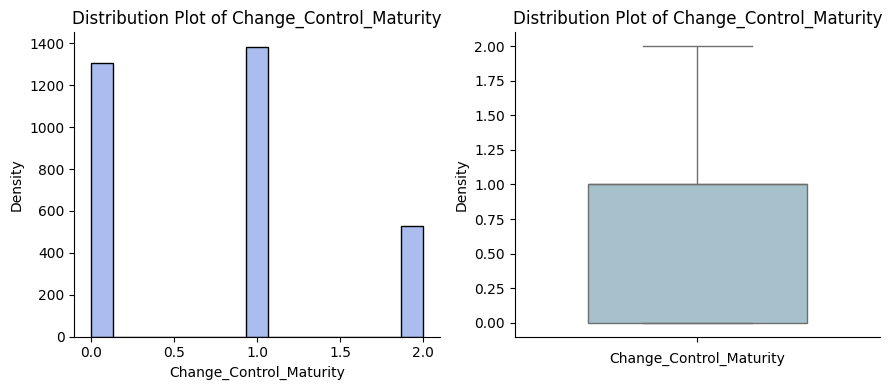

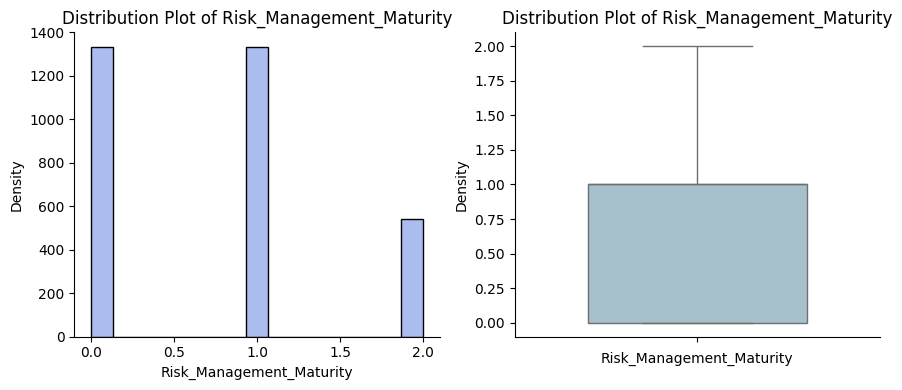

In [ ]:
nan_col = ['Change_Control_Maturity', 'Risk_Management_Maturity']
for i in range(len(nan_col)):
    plt.figure(figsize=(9,4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[nan_col[i]],color='#8EA7E9')
    plt.xlabel(nan_col[i])
    plt.ylabel('Density')
    plt.title(f'Distribution Plot of {nan_col[i]}')
    sns.despine()
    plt.subplot(1, 2, 2)
    sns.boxplot(df[nan_col[i]],color='#A0C3D2',width=0.6, fliersize=5)
    plt.xlabel(nan_col[i])
    plt.ylabel('Density')
    plt.title(f'Distribution Plot of {nan_col[i]}')
    sns.despine()
    plt.tight_layout()
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=['Tech_Environment_Stability'])
df['Change_Control_Maturity'] = df['Change_Control_Maturity'].isna().astype(int)
df['Change_Control_Maturity'] = df['Change_Control_Maturity'].fillna(df['Change_Control_Maturity'].mode(-1))
df['Risk_Management_Maturity'] = df['Risk_Management_Maturity'].isna().astype(int)
df['Risk_Management_Maturity'] = df['Risk_Management_Maturity'].fillna(df['Risk_Management_Maturity'].mode(-1))

# Check duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

# Handling outliers

In [ ]:
df.describe()

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Project_Phase,...,Resource_Contention_Level,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
count,4000.000000,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,15.388250,1.143032e+06,17.147750,6.192525,11.130500,1.459500,1.973750,3.127750,1.638080,1.971500,...,1.943500,2.360250,1.483000,0.19500,0.197750,1.496000,6.492500,4.074500,1.011325,2.438500
std,9.220969,5.908781e+05,6.926609,2.212538,4.425875,0.865186,1.750093,1.609216,1.170451,1.423269,...,0.817909,0.992329,1.039702,0.39625,0.398352,0.933382,3.476416,2.883926,0.031694,1.015123
min,2.000000,1.593555e+05,2.000000,1.620000,2.000000,0.000000,0.000000,0.000000,0.010000,0.000000,...,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,9.000000,6.925329e+05,12.000000,4.460000,8.000000,1.000000,1.000000,2.000000,0.760000,1.000000,...,1.000000,2.000000,1.000000,0.00000,0.000000,1.000000,4.000000,2.000000,1.000000,2.000000
50%,13.000000,1.007472e+06,17.000000,6.015000,10.000000,2.000000,2.000000,3.000000,1.370000,2.000000,...,2.000000,2.000000,1.000000,0.00000,0.000000,1.000000,7.000000,3.000000,1.000000,2.000000
75%,20.000000,1.475870e+06,22.000000,7.862500,14.000000,2.000000,3.000000,4.000000,2.230000,3.000000,...,3.000000,3.000000,2.000000,0.00000,0.000000,2.000000,10.000000,6.000000,1.000000,3.000000
max,50.000000,3.768354e+06,36.000000,10.000000,29.000000,3.000000,10.000000,7.000000,8.840000,4.000000,...,3.000000,4.000000,3.000000,1.00000,1.000000,3.000000,12.000000,17.000000,1.100000,4.000000


In [ ]:
def outlier(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers = outliers.drop_duplicates()

    return outliers

In [ ]:
numerical_col = df.select_dtypes(include='number').columns
for i in numerical_col:
  if df[i].nunique() > 2:
    print(f'Outliers in {i} : {outlier(df,i).shape[0]}')

Outliers in Team_Size : 152
Outliers in Project_Budget_USD : 72
Outliers in Estimated_Timeline_Months : 0
Outliers in Complexity_Score : 0
Outliers in Stakeholder_Count : 38
Outliers in Team_Experience_Level : 0
Outliers in Past_Similar_Projects : 64
Outliers in External_Dependencies_Count : 0
Outliers in Change_Request_Frequency : 117
Outliers in Project_Phase : 0
Outliers in Requirement_Stability : 0
Outliers in Team_Turnover_Rate : 16
Outliers in Vendor_Reliability_Score : 16
Outliers in Historical_Risk_Incidents : 263
Outliers in Communication_Frequency : 113
Outliers in Regulatory_Compliance_Level : 0
Outliers in Geographical_Distribution : 0
Outliers in Stakeholder_Engagement_Level : 0
Outliers in Schedule_Pressure : 340
Outliers in Budget_Utilization_Rate : 0
Outliers in Executive_Sponsorship : 0
Outliers in Market_Volatility : 0
Outliers in Integration_Complexity : 0
Outliers in Resource_Availability : 0
Outliers in Priority_Level : 0
Outliers in Organizational_Change_Frequency

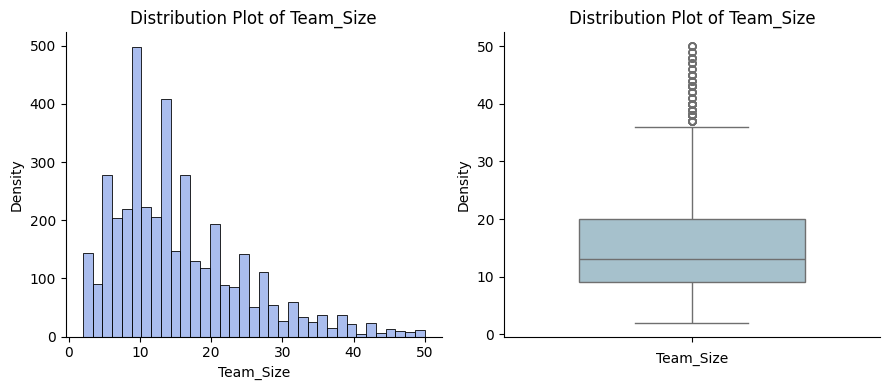

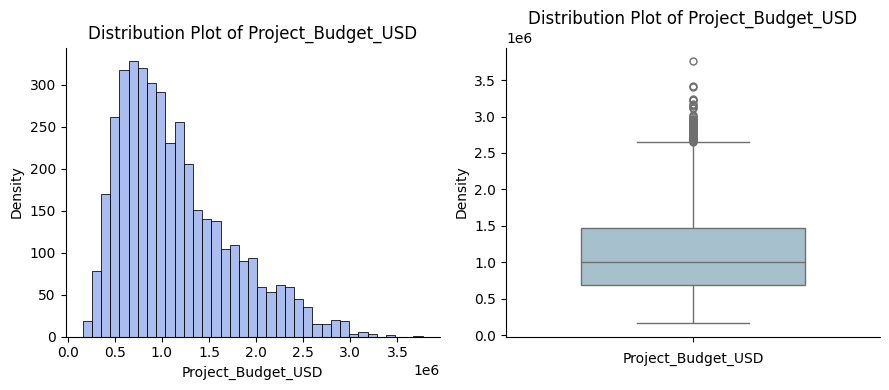

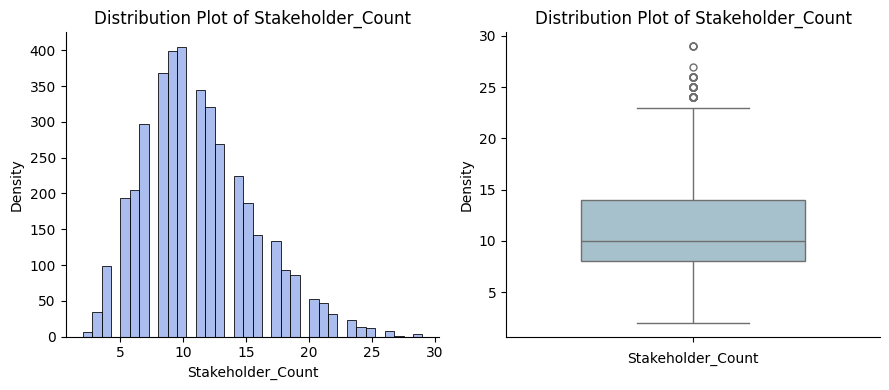

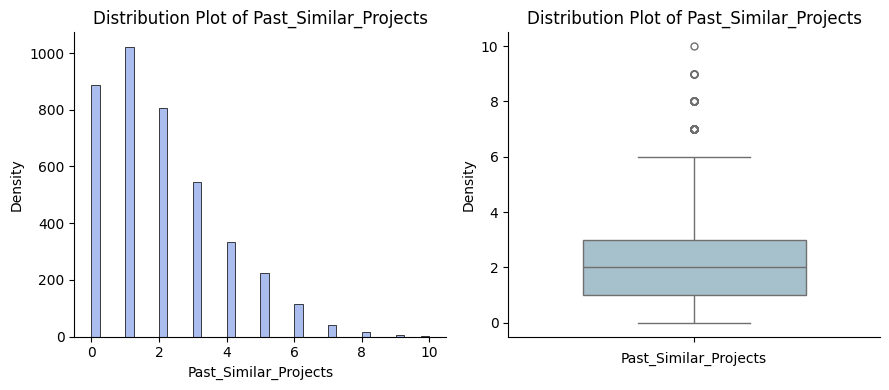

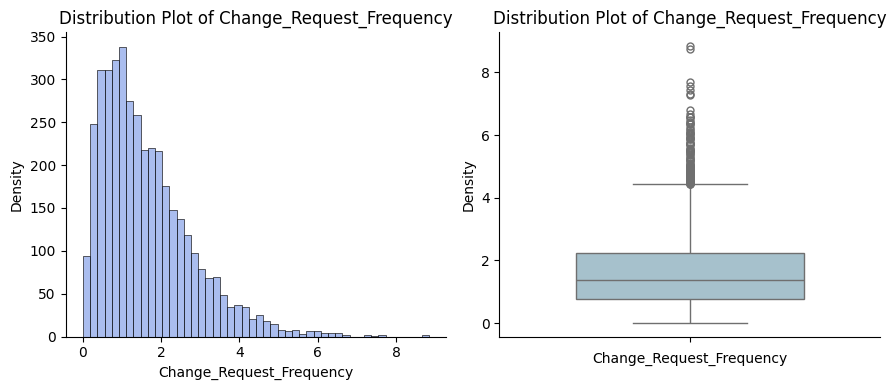

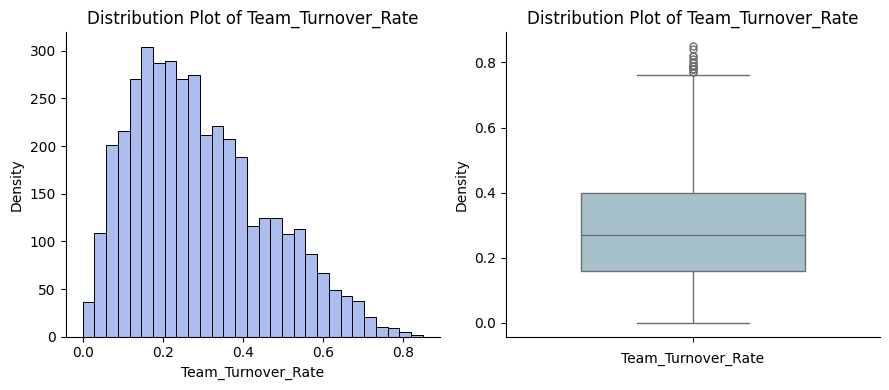

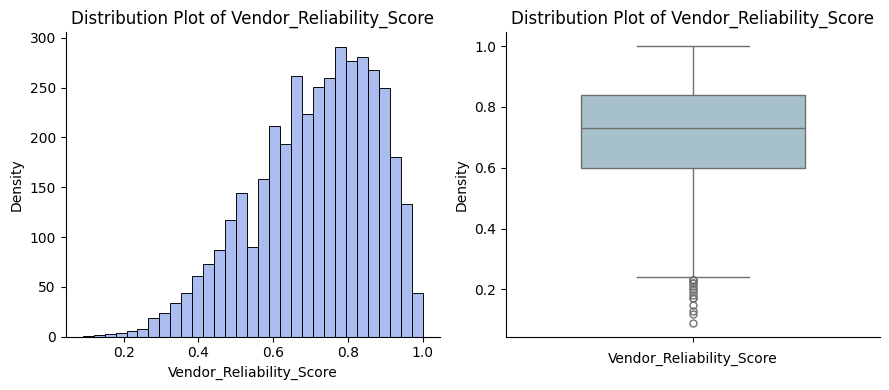

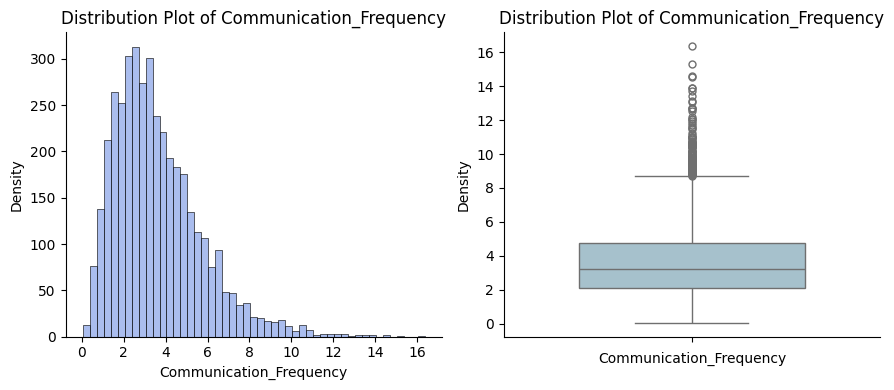

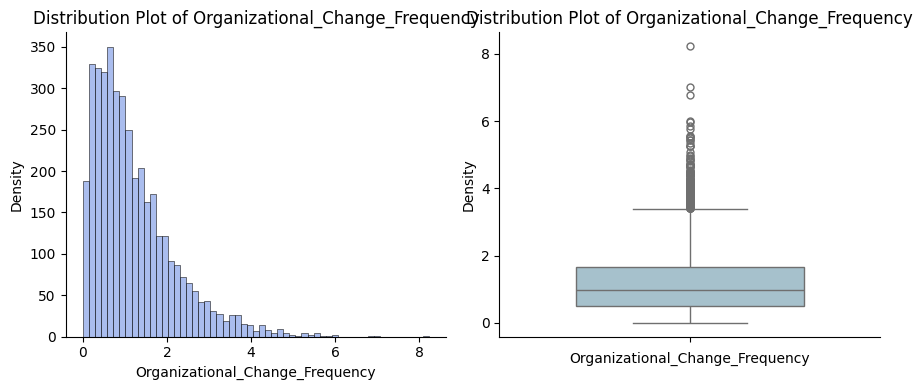

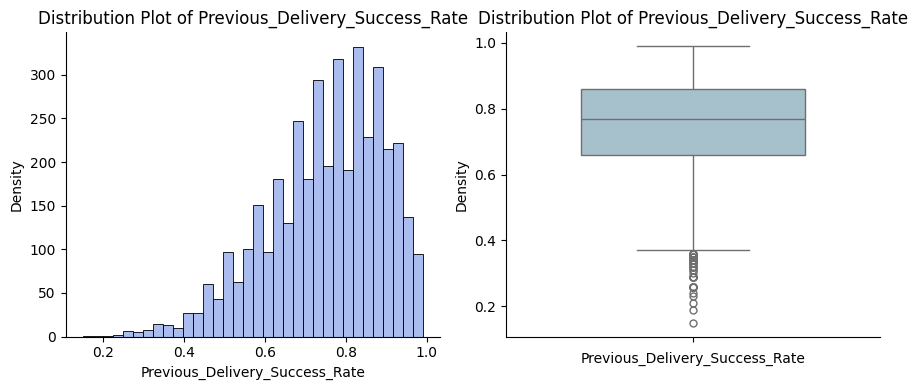

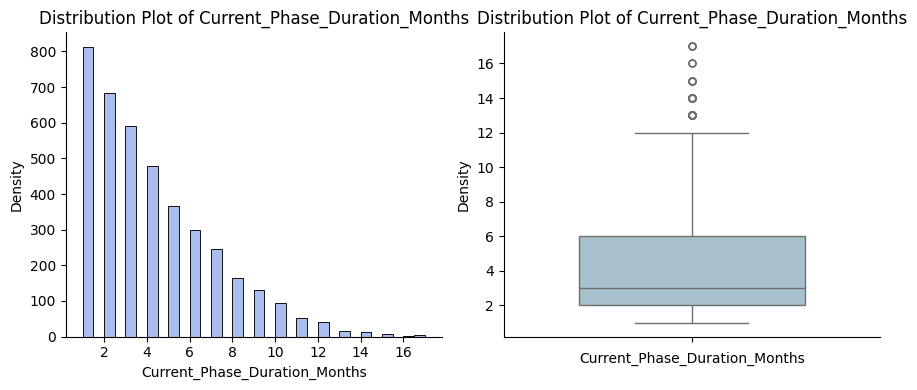

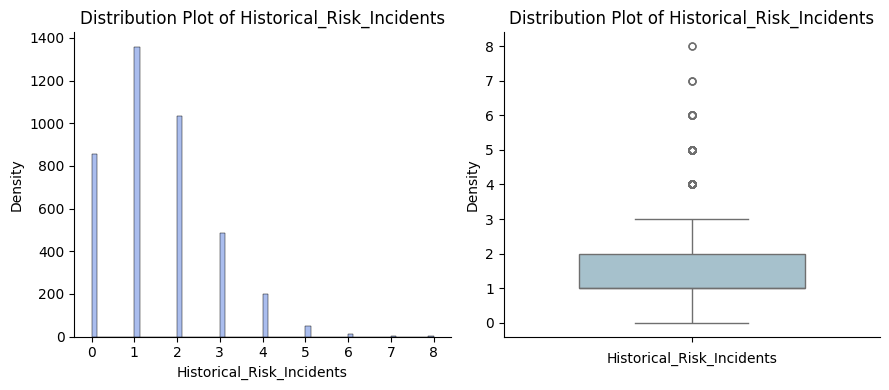

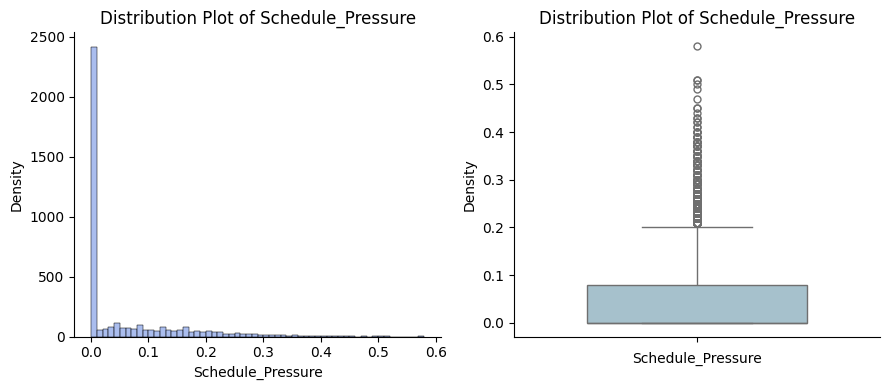

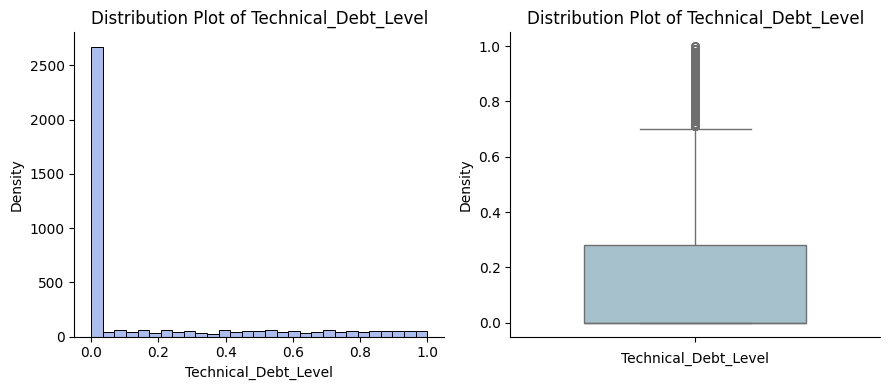

In [ ]:
out_cols = ['Team_Size', 'Project_Budget_USD', 'Stakeholder_Count', 'Past_Similar_Projects', 'Change_Request_Frequency', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Communication_Frequency', 'Organizational_Change_Frequency', 'Previous_Delivery_Success_Rate', 'Current_Phase_Duration_Months', 'Historical_Risk_Incidents', 'Schedule_Pressure', 'Technical_Debt_Level']
for i in range(len(out_cols)):
    plt.figure(figsize=(9,4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[out_cols[i]],color='#8EA7E9')
    plt.xlabel(out_cols[i])
    plt.ylabel('Density')
    plt.title(f'Distribution Plot of {out_cols[i]}')
    sns.despine()
    plt.subplot(1, 2, 2)
    sns.boxplot(df[out_cols[i]],color='#A0C3D2',width=0.6, fliersize=5)
    plt.xlabel(out_cols[i])
    plt.ylabel('Density')
    plt.title(f'Distribution Plot of {out_cols[i]}')
    sns.despine()
    plt.tight_layout()
plt.tight_layout()
plt.show()

# Encoding

In [ ]:
nominal_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

df = pd.get_dummies(df, columns=nominal_columns, drop_first=True, dtype=int)
df

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Project_Phase,...,Funding_Source_Mixed,Org_Process_Maturity_Defined,Org_Process_Maturity_Managed,Org_Process_Maturity_Optimizing,Contract_Type_Fixed-Price,Contract_Type_Hybrid,Contract_Type_Time & Materials,Team_Colocation_Fully Remote,Team_Colocation_Hybrid,Team_Colocation_Partially Colocated
0,32,1526276.55,32,9.70,16,1,3,3,1.05,1,...,0,0,1,0,0,0,1,0,0,0
1,2,390790.15,9,2.72,9,2,0,2,2.61,2,...,0,0,0,1,0,0,0,1,0,0
2,2,246674.76,6,2.04,7,2,1,0,0.83,0,...,0,0,0,0,0,0,0,0,1,0
3,12,1427830.63,17,7.54,16,2,0,5,2.42,0,...,1,0,1,0,0,1,0,0,1,0
4,24,1696746.64,24,6.68,17,0,0,2,0.16,2,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,9,731548.97,14,5.40,9,1,4,3,1.09,3,...,0,0,0,0,1,0,0,0,1,0
3996,9,492981.40,9,2.69,8,1,5,3,2.11,0,...,0,1,0,0,1,0,0,0,1,0
3997,12,1097040.65,24,8.82,10,0,2,4,0.52,1,...,1,0,0,0,0,0,1,1,0,0
3998,26,2900977.55,28,10.00,26,0,1,6,1.19,1,...,1,1,0,0,1,0,0,1,0,0


# Split data

In [ ]:
x = df.drop('Risk_Level', axis = 1)
y = df['Risk_Level']

# Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x= scaler.fit_transform(x)

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15,random_state=44)

lr = LogisticRegression(max_iter=1000)
model = lr.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.82      0.76      0.79       144
           2       0.64      0.71      0.67       202
           3       0.58      0.55      0.57       137
           4       0.78      0.74      0.76       117

    accuracy                           0.69       600
   macro avg       0.70      0.69      0.70       600
weighted avg       0.70      0.69      0.69       600

